<a href="https://colab.research.google.com/github/ashish0726/project-01/blob/main/BigMart_Sales_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
import os
print(os.listdir())

['.config', 'Test.csv', 'Train.csv', 'sample_data']


In [18]:
train = pd.read_csv("Train.csv")
test = pd.read_csv("Test.csv")

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Train Shape: (8523, 12)
Test Shape: (5681, 11)


In [19]:
train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [20]:
train.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [21]:
train['Item_Weight'] = train['Item_Weight'].fillna(train['Item_Weight'].mean())
train['Outlet_Size'] = train['Outlet_Size'].fillna(train['Outlet_Size'].mode()[0])

In [22]:
train = train.drop(['Item_Identifier', 'Outlet_Identifier'], axis=1)

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cols = ['Item_Fat_Content', 'Item_Type', 'Outlet_Size',
        'Outlet_Location_Type', 'Outlet_Type']

for col in cols:
    train[col] = le.fit_transform(train[col])

In [24]:
from sklearn.model_selection import train_test_split

X = train.drop('Item_Outlet_Sales', axis=1)
y = train['Item_Outlet_Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100)

model.fit(X_train, y_train)

RandomForestRegressor()

In [26]:
pred = model.predict(X_test)

In [27]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 1095.7734599611676
R2 Score: 0.5582293233089569


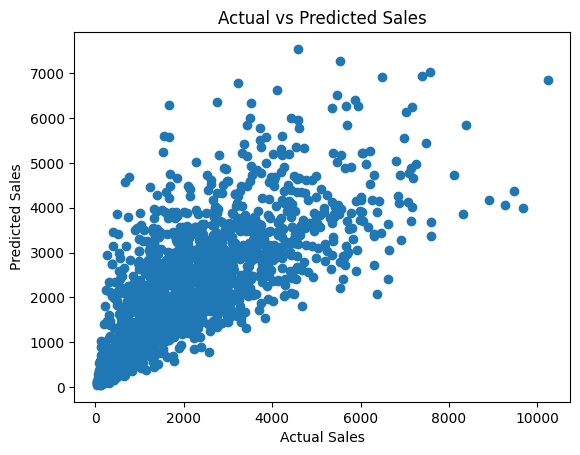

In [28]:
plt.scatter(y_test, pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()